# Notes:

This notebook quantifies the protein-level association between age-associated structural change and native non-covalent lasso entanglement (NCLE) status in the yeast proteome.
Protein length is included as a covariate to control for confounding.

In [1]:
import sys
from datetime import datetime

import pandas as pd
import numpy as np
import scipy as sp
import scipy.stats as ss

import statsmodels as sm
from statsmodels.stats.contingency_tables import Table2x2
import statsmodels.formula.api as smf

import matplotlib as mpl
import matplotlib.pyplot as plt

from utils import *

In [2]:
# Date running analysis
RUN_START = datetime.now().astimezone()

print("=" * 50)
print("RUN START")
print("=" * 50)
print(f"{'date':12s}: {RUN_START.strftime('%Y-%m-%d')}")
print(f"{'time':12s}: {RUN_START.strftime('%H:%M:%S %Z')}")
print(f"{'iso':12s}: {RUN_START.isoformat()}")
print("=" * 50)


# Logging: software version
versions = {
    "python": sys.version.replace("\n", " "),
    "pandas": get_version(pd, "pandas"),
    "numpy": get_version(np, "numpy"),
    "scipy": get_version(sp, "scipy"),
    "matplotlib": get_version(mpl, "matplotlib"),
    "statsmodels": get_version(sm, "statsmodels"),
}

# Pretty print
print("Software versions:\n")
for k, v in versions.items():
    print(f"{k:12s}: {v}")

RUN START
date        : 2026-03-31
time        : 14:01:00 +07
iso         : 2026-03-31T14:01:00.938725+07:00
Software versions:

python      : 3.13.12 | packaged by conda-forge | (main, Feb  5 2026, 05:58:33) [Clang 19.1.7 ]
pandas      : 2.3.3
numpy       : 2.4.2
scipy       : 1.17.0
matplotlib  : 3.10.8
statsmodels : 0.14.6


In [3]:
# load custom setting for figures
set_nature_style()

In [4]:
# Logging: checksum input files
input_data = ['../data/SC_Ent.pkl']
df_files = pd.DataFrame([
    file_info(f) for f in input_data
])

with pd.option_context("display.max_colwidth", None):
    display(df_files)

,path,size_bytes,sha256
0,../data/SC_Ent.pkl,1640408,fbb3e5435702b31ecd2576fedc14e564b0b50baf85c0a5643db92f6a86f10153


# Load data

In [5]:
df_SC_Ent= pd.read_pickle('../data/SC_Ent.pkl')
df_SC_Ent

,SGDID,Uniprot,SC,length_AF,entangled,asphericity,fraction_idp,Knot,cov_lasso,entangled_residues,Cutsite_residues,clustered_entangled_residues
0,S000002468,Q12298,0,539,1,0.139968,0.011132,0,0,"[26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 4...",[],"[27, 31, 34, 35, 36, 38, 39, 40, 41, 42, 43, 4..."
1,S000000094,P35842,0,467,1,0.097823,0.051392,0,0,"[21, 23, 30, 31, 32, 33, 34, 35, 37, 38, 41, 4...",[],"[32, 33, 34, 35, 37, 38, 41, 46, 47, 67, 68, 6..."
2,S000002490,P38961,0,392,1,0.108081,0.295918,0,0,"[177, 178, 179, 180, 181, 182, 183, 184, 190, ...",[],"[181, 193, 266, 267, 268, 290, 292, 293, 294, ..."
3,S000003653,P46956,0,311,1,0.311604,0.099678,0,0,"[64, 65, 68, 69, 70, 71, 72, 73, 74, 75, 78, 1...",[],"[203, 210, 211, 212, 213, 252, 253, 254, 255, ..."
4,S000002198,P12945,0,854,0,0.074009,0.069087,0,0,[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...
2251,S000001943,P43619,0,295,1,0.383145,0.071186,0,0,"[1, 2, 3, 4, 5, 8, 10, 12, 13, 14, 15, 16, 17,...",[],"[15, 18, 19, 20, 21, 22, 23, 24, 25, 26, 48, 4..."
2252,S000003720,P46984,0,123,0,0.230204,1.000000,0,0,[],[],[]
2253,S000005560,Q12013,0,749,0,0.224206,0.157543,0,0,[],[],[]
2254,S000005185,P11412,1,505,1,0.142002,0.017822,0,0,"[6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...","[394, 395, 396, 397, 398, 399, 400, 401, 402]","[10, 11, 12, 13, 14, 15, 16, 17, 18, 23, 24, 2..."


# Get OR using contingency table

SC               SC = Yes  SC = No
entangled                         
Entangled = Yes       368     1318
Entangled = No         70      500
Crude Odds Ratio: 1.994
95% CI: [1.514, 2.627]
Fisher exact P-value: 3.252407554089501e-07
--------------------------------------------------


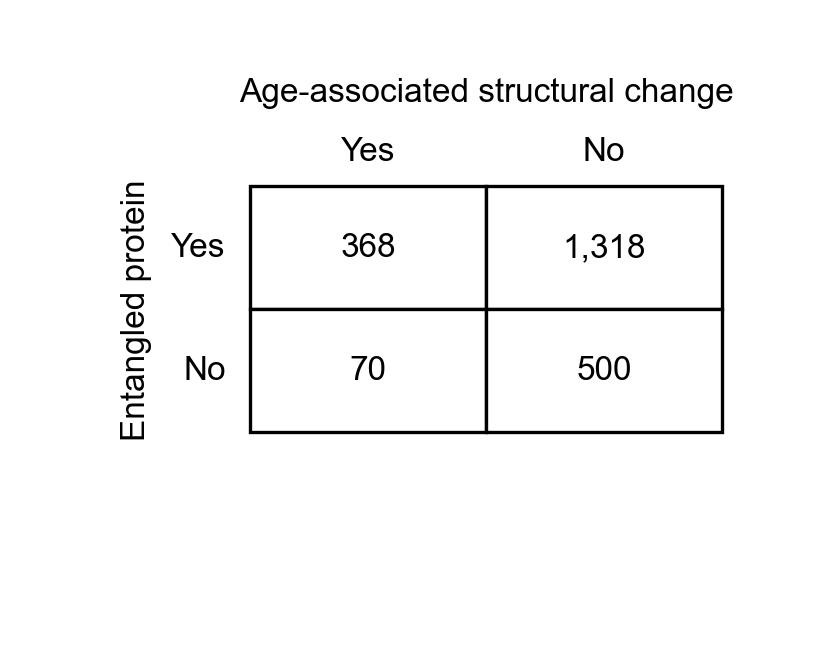

In [6]:
# build contingency table: Yes first, then No
contingency = (
    pd.crosstab(
        df_SC_Ent["entangled"],
        df_SC_Ent["SC"]
    )
    .reindex(index=[1, 0], columns=[1, 0])   # <-- this enforces Yes first
    .rename(
        index={1: "Entangled = Yes", 0: "Entangled = No"},
        columns={1: "SC = Yes", 0: "SC = No"},
    )
)
print(contingency)

# convert to numpy array in [[a,b],[c,d]] format
table = contingency.to_numpy()

ct = Table2x2(table)

odds_ratio, pvalue = ss.fisher_exact(table)
ci_low, ci_high = ct.oddsratio_confint(alpha=0.05, method="exact")
print(f"Crude Odds Ratio: {odds_ratio:.3f}")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Fisher exact P-value: {pvalue}")
print('-'*50)

fig, ax = draw_contingency_table(table)
fig.savefig('figs/Protein_Level_contingency_table.pdf')
fig.savefig('figs/Protein_Level_contingency_table.png', dpi=300)

In [7]:
# get the counts
SC_Ent = len(df_SC_Ent[(df_SC_Ent.SC==1) & (df_SC_Ent.entangled == 1)])
NSC_NEnt = len(df_SC_Ent[(df_SC_Ent.SC==0) & (df_SC_Ent.entangled == 0)])
SC_NEnt = len(df_SC_Ent[(df_SC_Ent.SC==1) & (df_SC_Ent.entangled == 0)])
NSC_Ent = len(df_SC_Ent[(df_SC_Ent.SC==0) & (df_SC_Ent.entangled == 1)])

print("The prevalence of age-associated structural changes across the set of mass-spectrometric-observed proteins:")
print(f"Structural change proteins: {SC_Ent + SC_NEnt}")
print(f"Total Proteins: {SC_Ent + NSC_Ent + SC_NEnt + NSC_NEnt}")
print(f"Percentage: {100*(SC_Ent + SC_NEnt)/(SC_Ent + NSC_Ent + SC_NEnt + NSC_NEnt):.3f} %")

The prevalence of age-associated structural changes across the set of mass-spectrometric-observed proteins:
Structural change proteins: 438
Total Proteins: 2256
Percentage: 19.415 %


In [8]:
print("Prevalent of age-associated structural change protein in entangled proteins:")
print(f"Entangled proteins exhibit structural change: {SC_Ent}")
print(f"Total Entangled Proteins: {(SC_Ent+NSC_Ent)}")
print(f"Percentage: {100*(SC_Ent)/(SC_Ent+NSC_Ent):.3f} %")

Prevalent of age-associated structural change protein in entangled proteins:
Entangled proteins exhibit structural change: 368
Total Entangled Proteins: 1686
Percentage: 21.827 %


In [9]:
print("Prevalent of age-associated structural change protein in non-entangled proteins:")
print(f"Non-entangled proteins exhibit Structural change: {SC_NEnt}")
print(f"Total Non-entangled Proteins: {(SC_NEnt+NSC_NEnt)}")
print(f"Percentage: {100*(SC_NEnt)/(SC_NEnt+NSC_NEnt):.3f} %")

Prevalent of age-associated structural change protein in non-entangled proteins:
Non-entangled proteins exhibit Structural change: 70
Total Non-entangled Proteins: 570
Percentage: 12.281 %


# Logistic Regression

In [10]:
# Standardize 'length_AF' using z-score
df_SC_Ent['length_z'] = (df_SC_Ent['length_AF'] - df_SC_Ent['length_AF'].mean()) / df_SC_Ent['length_AF'].std()

In [11]:
df_SC_Ent

,SGDID,Uniprot,SC,length_AF,entangled,asphericity,fraction_idp,Knot,cov_lasso,entangled_residues,Cutsite_residues,clustered_entangled_residues,length_z
0,S000002468,Q12298,0,539,1,0.139968,0.011132,0,0,"[26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 4...",[],"[27, 31, 34, 35, 36, 38, 39, 40, 41, 42, 43, 4...",0.179299
1,S000000094,P35842,0,467,1,0.097823,0.051392,0,0,"[21, 23, 30, 31, 32, 33, 34, 35, 37, 38, 41, 4...",[],"[32, 33, 34, 35, 37, 38, 41, 46, 47, 67, 68, 6...",-0.024684
2,S000002490,P38961,0,392,1,0.108081,0.295918,0,0,"[177, 178, 179, 180, 181, 182, 183, 184, 190, ...",[],"[181, 193, 266, 267, 268, 290, 292, 293, 294, ...",-0.237167
3,S000003653,P46956,0,311,1,0.311604,0.099678,0,0,"[64, 65, 68, 69, 70, 71, 72, 73, 74, 75, 78, 1...",[],"[203, 210, 211, 212, 213, 252, 253, 254, 255, ...",-0.466648
4,S000002198,P12945,0,854,0,0.074009,0.069087,0,0,[],[],[],1.071726
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2251,S000001943,P43619,0,295,1,0.383145,0.071186,0,0,"[1, 2, 3, 4, 5, 8, 10, 12, 13, 14, 15, 16, 17,...",[],"[15, 18, 19, 20, 21, 22, 23, 24, 25, 26, 48, 4...",-0.511978
2252,S000003720,P46984,0,123,0,0.230204,1.000000,0,0,[],[],[],-0.999271
2253,S000005560,Q12013,0,749,0,0.224206,0.157543,0,0,[],[],[],0.774250
2254,S000005185,P11412,1,505,1,0.142002,0.017822,0,0,"[6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...","[394, 395, 396, 397, 398, 399, 400, 401, 402]","[10, 11, 12, 13, 14, 15, 16, 17, 18, 23, 24, 2...",0.082974


In [12]:
model = smf.logit('SC ~ entangled + length_z', data=df_SC_Ent)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.484882
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                     SC   No. Observations:                 2256
Model:                          Logit   Df Residuals:                     2253
Method:                           MLE   Df Model:                            2
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.01483
Time:                        14:01:02   Log-Likelihood:                -1093.9
converged:                       True   LL-Null:                       -1110.4
Covariance Type:            nonrobust   LLR p-value:                 7.025e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.0467      0.132    -15.452      0.000      -2.306      -1.787
entangled      0.7907      0.

In [13]:
summary_df = summarize_logit(result)
print(summary_df.to_string(float_format=lambda x: f"{x:.3f}"))

            coef    OR  OR_ci_lower  OR_ci_upper  pvalue      p_fmt
Intercept -2.047 0.129        0.100        0.167   0.000  7.357e-54
entangled  0.791 2.205        1.654        2.938   0.000  6.818e-08
length_z  -0.146 0.864        0.767        0.974   0.017      0.017


# calculate the odds

In [ ]:
# Odd of entangled proteins exhibit age-associated structural changes
# Coefficients and covariance matrix
params = result.params
cov = result.cov_params()

# calculate odds and CI for entangled = 1, length_z = 0
a = np.array([1, 1, 0])  # intercept, entangled, length_z

# Compute logit
logit = np.dot(a, params)

# Variance and standard error
var_logit = np.dot(a, np.dot(cov, a))
se_logit = np.sqrt(var_logit)

# CI in logit scale
logit_lower = logit - 1.96 * se_logit
logit_upper = logit + 1.96 * se_logit

# Convert to odds
E_odds = np.exp(logit)
E_ci_lower = np.exp(logit_lower)
E_ci_upper = np.exp(logit_upper)

print(f"Odds: {E_odds:.3f} (95% CI: [{E_ci_lower:.3f}, {E_ci_upper:.3f}]")

Odds: 0.285 (95% CI: [0.254, 0.320]


In [ ]:
# Odd of non-entangled proteins exhibit age-associated structural change
# Coefficients and covariance matrix
params = result.params
cov = result.cov_params()

# calculate odds and CI for entangled = 0, length_z = 0
a = np.array([1, 0, 0])  # intercept, entangled, length_z

# Compute logit
logit = np.dot(a, params)

# Variance and standard error
var_logit = np.dot(a, np.dot(cov, a))
se_logit = np.sqrt(var_logit)

# CI in logit scale
logit_lower = logit - 1.96 * se_logit
logit_upper = logit + 1.96 * se_logit

# Convert to odds
NE_odds = np.exp(logit)
NE_ci_lower = np.exp(logit_lower)
NE_ci_upper = np.exp(logit_upper)

print(f"Odds: {NE_odds:.3f} (95% CI: [{NE_ci_lower:.3f}, {NE_ci_upper:.3f}]")

Odds: 0.129 (95% CI: [0.100, 0.167]


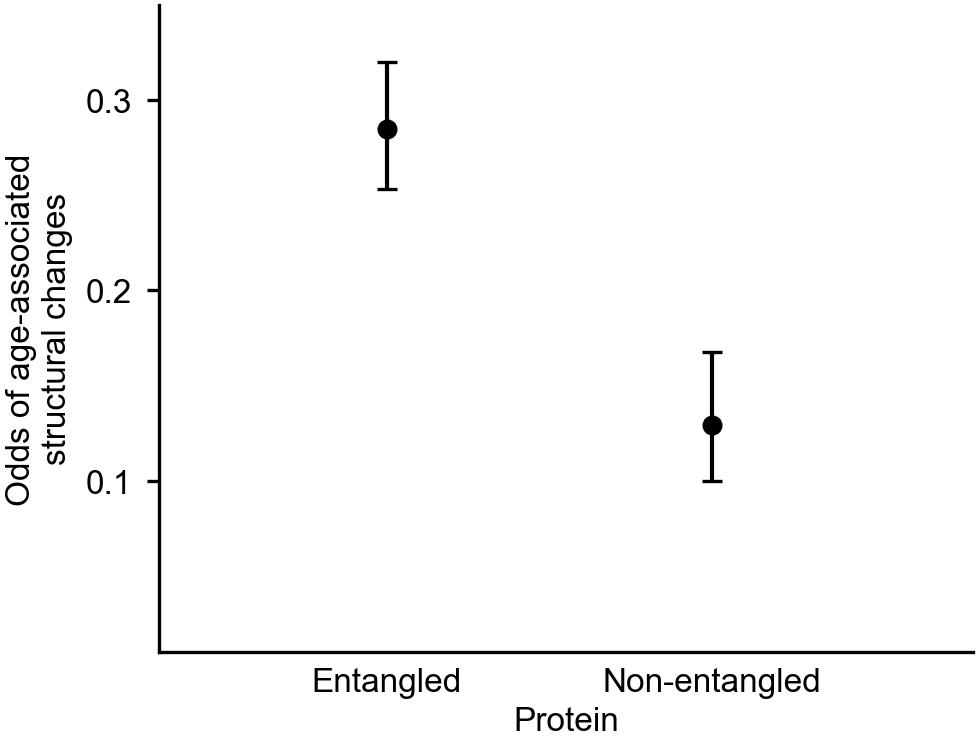

In [16]:
data = {
            "Entangled": [E_odds, E_ci_lower, E_ci_upper],
            "Non-entangled": [NE_odds, NE_ci_lower, NE_ci_upper]
        }
data

fig_odds, ax_odds = plot_odds(
    data=data,
    figsize=(3.50, 2.80),
    yticks=np.arange(0, 0.41, 0.1),
    xlim=(0, 2.5),
    ylim=(0.01, 0.35),
)

plt.show()
fig_odds.savefig('figs/Protein_Level_LR_odds.pdf')
fig_odds.savefig('figs/Protein_Level_LR_odds.png', dpi=300)

In [17]:
RUN_END = datetime.now().astimezone()

print("\n" + "=" * 50)
print("RUN END")
print("=" * 50)
print(f"{'date':12s}: {RUN_END.strftime('%Y-%m-%d')}")
print(f"{'time':12s}: {RUN_END.strftime('%H:%M:%S %Z')}")
print(f"{'iso':12s}: {RUN_END.isoformat()}")

# Duration
duration = RUN_END - RUN_START
print(f"{'duration':12s}: {str(duration).split('.')[0]}")  # remove microseconds

print("=" * 50)


RUN END
date        : 2026-03-31
time        : 14:01:02 +07
iso         : 2026-03-31T14:01:02.852235+07:00
duration    : 0:00:01
